### Discover distribution parameter

##### 1. Reproduce example presented during the lecture (anti-viral drug).

In [7]:
import arviz as az
import pymc as pm  
import numpy as np

def generate_bernoulli_data(occurrences):
    with pm.Model() as model:
        p = pm.Uniform('p', lower=0, upper=1)
        obs = pm.Bernoulli('obs', p, observed=occurrences)
        idata = pm.sample(2000, tune=2500)
    az.plot_trace(idata, show=True)

For 10 patients 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 12 seconds.


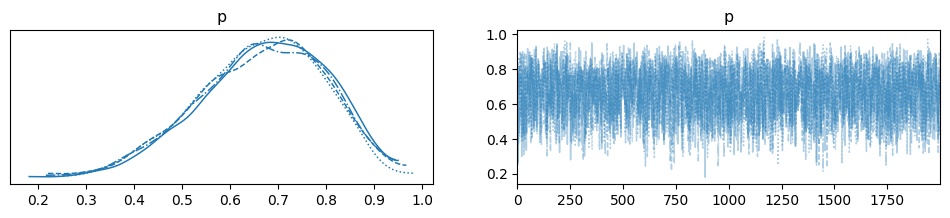

In [8]:
occurrences = [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
generate_bernoulli_data(occurrences)

For 100 patients 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 17 seconds.


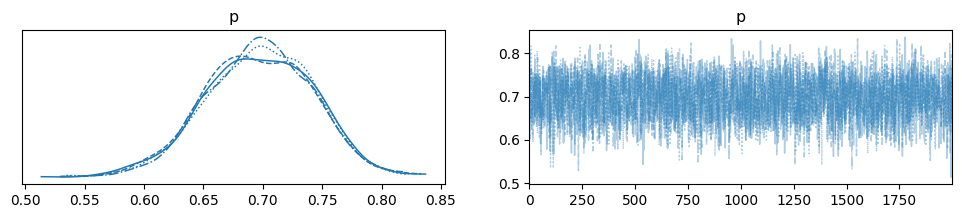

In [9]:
ones = np.ones(70)
zeros = np.zeros(30)
occurrences = np.concatenate([ones, zeros])
generate_bernoulli_data(occurrences)

### Compare distribution parameters

##### 1. Using exercise 5 as a basis, develop a model for comparing the parameter of two distributions: the distribution for patients taking anti-viral drug and for patients taking placebo (control group). Use deterministic variable to compare the resulting distribution parameters.

In [ ]:
def compare_bernoulli_distributions(treatment_data, control_data):
    with pm.Model() as model:
        p_treatment = pm.Uniform('p_treatment', lower=0, upper=1)
        p_control = pm.Uniform('p_control', lower=0, upper=1)
        
        obs_treatment = pm.Bernoulli('obs_treatment', p_treatment, observed=treatment_data)
        obs_control = pm.Bernoulli('obs_control', p_control, observed=control_data)
        
        p_diff = pm.Deterministic('p_difference', p_treatment - p_control)
        
        idata = pm.sample(2000, tune=2500, return_inferencedata=True)
    
    az.plot_trace(idata, var_names=['p_treatment', 'p_control', 'p_difference'], show=True)
    return idata

##### 2. Investigate and comment on the difference for the following cases:
- a. treatment group of 100 patients, 70% of which were cured, and control group of 100 patients, of which 50% were cured
- b. as above, but each group consisting of 1000 patients
- c. as b., but with the treatment group consisting of 10 patients. 